In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel('BASE_2_Clientes_Manga.xlsx')

In [33]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [34]:
target = "importancia_preco"

features = [
    "volume_tipico_compra_ton_mes",
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente",
    "frequencia_compra_mensal",
    "importancia_manga_produto_final_1a10"
]

cat_features = [
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente"
]

In [35]:
df_train = df[df[target].notna()].copy()
df_missing = df[df[target].isna()].copy()

X = df_train[features]
y = df_train[target]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train, cat_features=cat_features)

In [38]:
y_pred = model.predict(X_test)

# CatBoost às vezes retorna shape (n, 1)
if isinstance(y_pred, (np.ndarray,)) and y_pred.ndim > 1:
    y_pred = y_pred.ravel()

# se vier como lista de listas, também resolve
y_pred = np.array(y_pred).ravel()

# =========================
# MÉTRICAS (ordem prática)
# =========================
f1_macro = f1_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print("✅ Métricas (macro):")
print(f"1) F1 macro           : {f1_macro:.4f}")
print(f"2) Recall macro       : {recall_macro:.4f}")
print(f"3) Precision macro    : {precision_macro:.4f}")
print(f"4) Balanced accuracy  : {bal_acc:.4f}")

# =========================
# MATRIZ DE CONFUSÃO
# =========================
labels = sorted(pd.Series(y_test).dropna().unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"real_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

print("\n✅ Matriz de confusão:")
display(cm_df)

# =========================
# (extra útil) relatório por classe
# =========================
print("\n✅ Relatório por classe:")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Métricas (macro):
1) F1 macro           : 0.6562
2) Recall macro       : 0.6586
3) Precision macro    : 0.6555
4) Balanced accuracy  : 0.6586

✅ Matriz de confusão:


,pred_Alta,pred_Baixa,pred_Média
real_Alta,517,0,111
real_Baixa,4,168,67
real_Média,147,77,183



✅ Relatório por classe:
              precision    recall  f1-score   support

        Alta       0.77      0.82      0.80       628
       Baixa       0.69      0.70      0.69       239
       Média       0.51      0.45      0.48       407

    accuracy                           0.68      1274
   macro avg       0.66      0.66      0.66      1274
weighted avg       0.67      0.68      0.68      1274



In [39]:
from sklearn.metrics import f1_score

pred_train = model.predict(X_train).ravel()
pred_test  = model.predict(X_test).ravel()

print("F1 macro treino:", f1_score(y_train, pred_train, average="macro"))
print("F1 macro teste :", f1_score(y_test,  pred_test,  average="macro"))

F1 macro treino: 0.6751106413147324
F1 macro teste : 0.6562056274019658


In [40]:
target = "importancia_preco"

df_missing = df[df[target].isna()].copy()
df_observed = df[df[target].notna()].copy()
pred_missing = model.predict(df_missing[features])

# garante formato correto
import numpy as np
pred_missing = np.array(pred_missing).ravel()

df.loc[df[target].isna(), target] = pred_missing


In [41]:
df.isnull().sum()

tipo_cliente                            0
importancia_manga_produto_final_1a10    0
importancia_preco                       0
importancia_certificacoes               0
aceita_refugo_como_mp                   0
volume_tipico_compra_ton_mes            0
frequencia_compra_mensal                0
dtype: int64

🔢 NUMÉRICA × NUMÉRICA



,importancia_manga_produto_final_1a10,volume_tipico_compra_ton_mes,frequencia_compra_mensal
importancia_manga_produto_final_1a10,1.000000,-0.055716,0.121687
volume_tipico_compra_ton_mes,-0.055716,1.000000,-0.225574
frequencia_compra_mensal,0.121687,-0.225574,1.000000


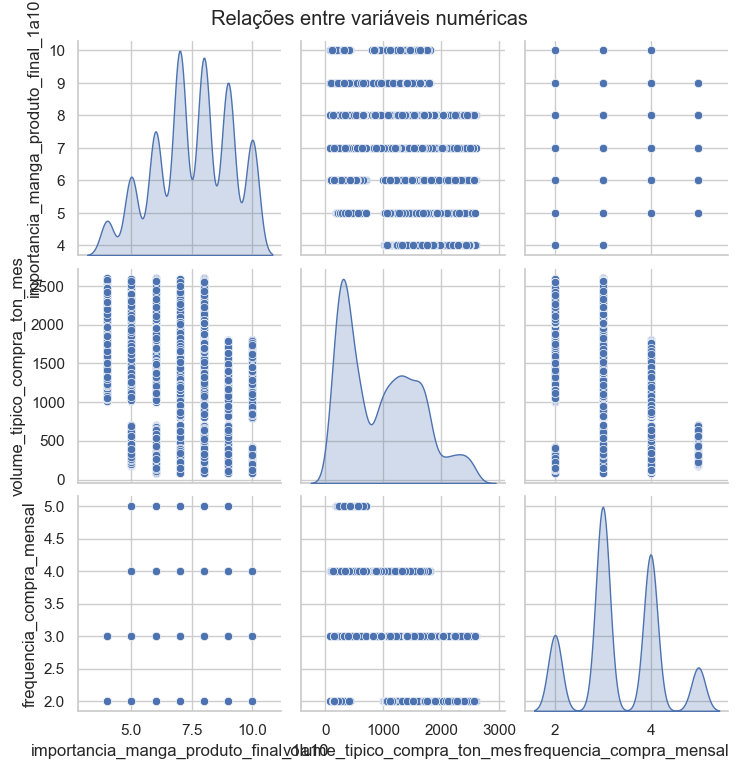


🔠 CATEGÓRICA × NUMÉRICA


📌 tipo_cliente × importancia_manga_produto_final_1a10


,count,mean,std,min,25%,50%,75%,max
tipo_cliente,,,,,,,,
B2B,6236.0,7.56,1.63,4.0,6.0,8.0,9.0,10.0
B2C,764.0,7.45,1.46,5.0,6.0,7.0,9.0,10.0


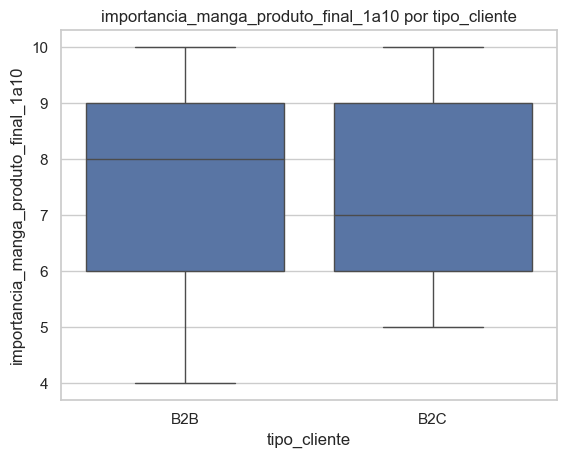


📌 tipo_cliente × volume_tipico_compra_ton_mes


,count,mean,std,min,25%,50%,75%,max
tipo_cliente,,,,,,,,
B2B,6236.0,999.77,666.70,80.0,356.00,997.0,1515.0,2600.0
B2C,764.0,717.97,461.73,180.0,357.75,556.0,1059.0,1800.0


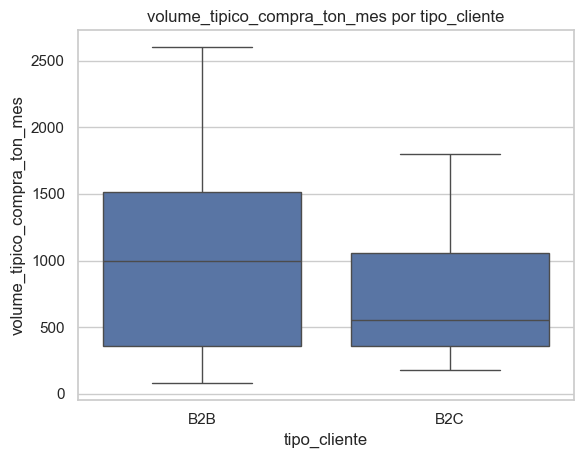


📌 tipo_cliente × frequencia_compra_mensal


,count,mean,std,min,25%,50%,75%,max
tipo_cliente,,,,,,,,
B2B,6236.0,3.28,0.84,2.0,3.0,3.0,4.0,5.0
B2C,764.0,3.88,0.77,3.0,3.0,4.0,4.0,5.0


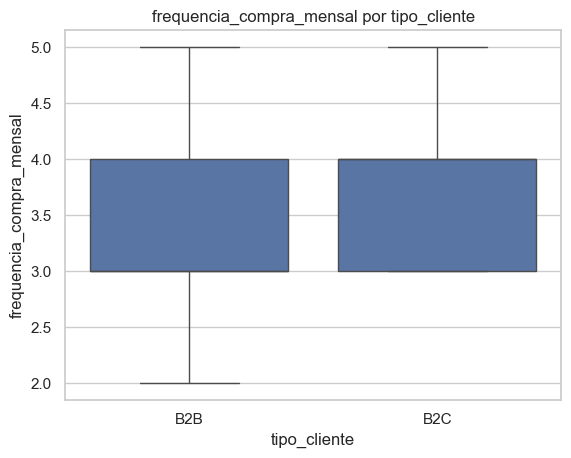


📌 aceita_refugo_como_mp × importancia_manga_produto_final_1a10


,count,mean,std,min,25%,50%,75%,max
aceita_refugo_como_mp,,,,,,,,
Não,2583.0,7.44,1.64,4.0,6.0,7.0,9.0,10.0
Sim,4417.0,7.60,1.59,4.0,7.0,8.0,9.0,10.0


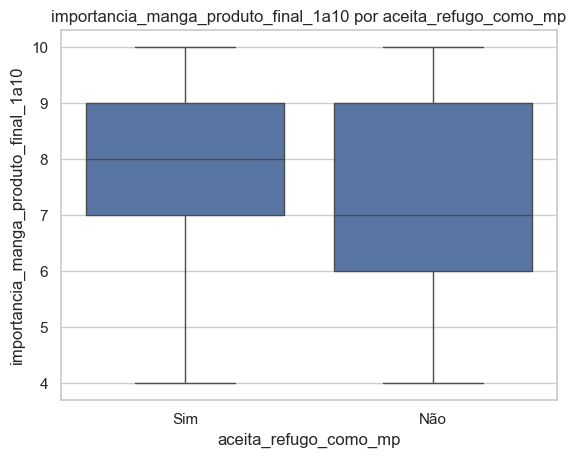


📌 aceita_refugo_como_mp × volume_tipico_compra_ton_mes


,count,mean,std,min,25%,50%,75%,max
aceita_refugo_como_mp,,,,,,,,
Não,2583.0,789.71,706.56,80.0,252.0,395.0,1306.5,2600.0
Sim,4417.0,1073.87,595.79,81.0,522.0,1091.0,1523.0,2600.0


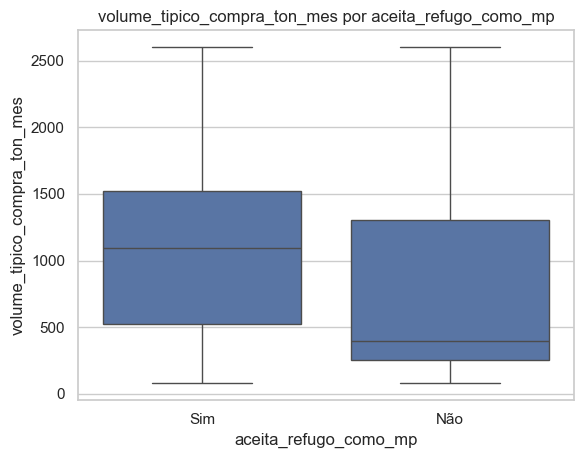


📌 aceita_refugo_como_mp × frequencia_compra_mensal


,count,mean,std,min,25%,50%,75%,max
aceita_refugo_como_mp,,,,,,,,
Não,2583.0,3.14,0.87,2.0,2.0,3.0,4.0,5.0
Sim,4417.0,3.47,0.81,2.0,3.0,3.0,4.0,5.0


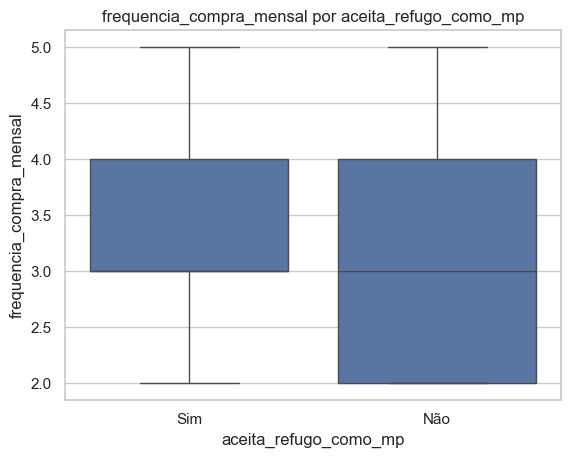


📌 importancia_preco × importancia_manga_produto_final_1a10


,count,mean,std,min,25%,50%,75%,max
importancia_preco,,,,,,,,
Alta,3590.0,7.55,1.66,4.0,7.0,8.0,9.0,10.0
Baixa,1202.0,7.73,1.46,5.0,6.0,8.0,9.0,10.0
Média,2208.0,7.43,1.59,4.0,6.0,8.0,9.0,10.0


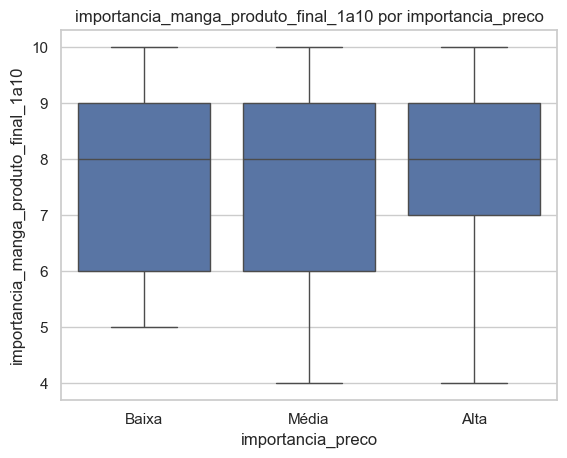


📌 importancia_preco × volume_tipico_compra_ton_mes


,count,mean,std,min,25%,50%,75%,max
importancia_preco,,,,,,,,
Alta,3590.0,1335.18,545.68,180.0,994.0,1340.5,1678.00,2600.0
Baixa,1202.0,288.73,135.19,80.0,183.0,276.0,365.00,700.0
Média,2208.0,744.00,582.20,81.0,314.0,512.5,1126.25,2579.0


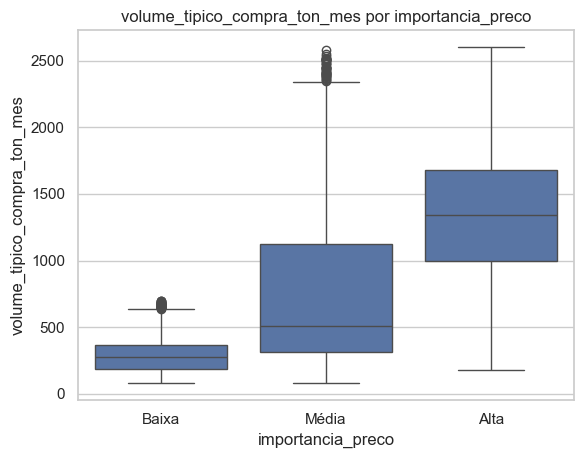


📌 importancia_preco × frequencia_compra_mensal


,count,mean,std,min,25%,50%,75%,max
importancia_preco,,,,,,,,
Alta,3590.0,3.27,0.77,2.0,3.0,3.0,4.0,5.0
Baixa,1202.0,3.24,0.93,2.0,2.0,3.0,4.0,5.0
Média,2208.0,3.53,0.90,2.0,3.0,3.0,4.0,5.0


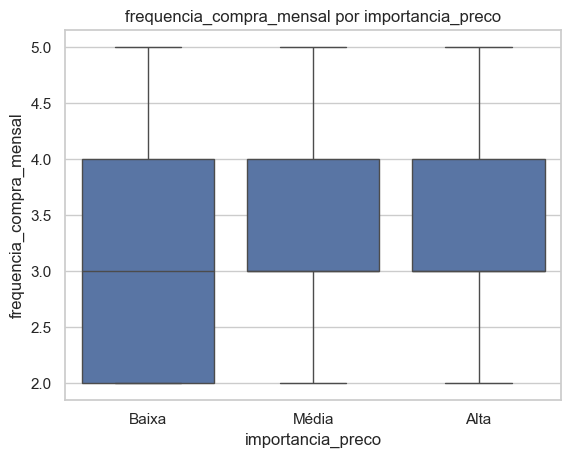


📌 importancia_certificacoes × importancia_manga_produto_final_1a10


,count,mean,std,min,25%,50%,75%,max
importancia_certificacoes,,,,,,,,
Alta,2043.0,7.09,1.70,4.0,6.0,7.0,8.0,10.0
Baixa,1878.0,7.52,1.50,5.0,6.0,8.0,9.0,10.0
Média,3079.0,7.86,1.54,4.0,7.0,8.0,9.0,10.0


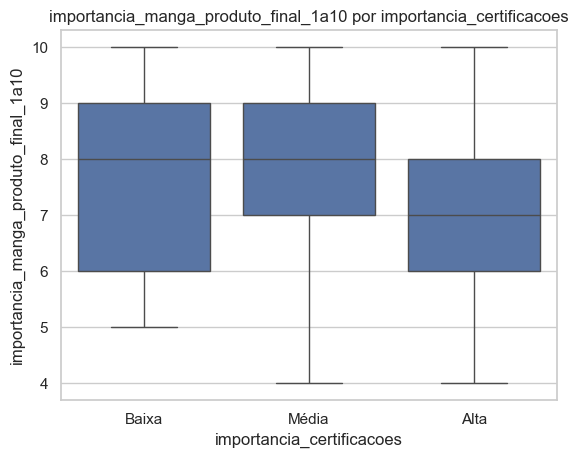


📌 importancia_certificacoes × volume_tipico_compra_ton_mes


,count,mean,std,min,25%,50%,75%,max
importancia_certificacoes,,,,,,,,
Alta,2043.0,975.53,851.78,80.0,238.0,395.0,1775.00,2600.0
Baixa,1878.0,770.17,474.90,180.0,385.0,599.5,1152.75,1800.0
Média,3079.0,1085.98,560.45,82.0,576.0,1130.0,1522.50,2561.0


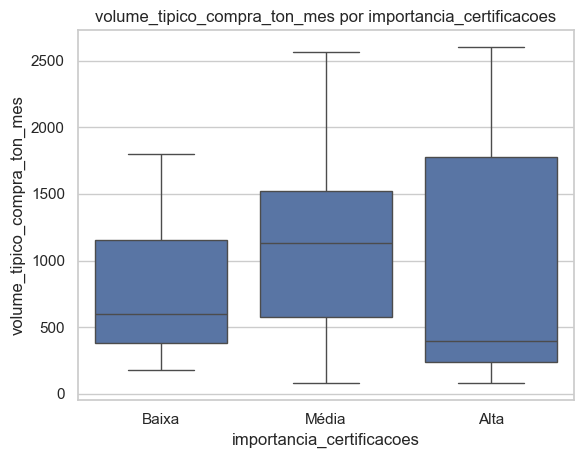


📌 importancia_certificacoes × frequencia_compra_mensal


,count,mean,std,min,25%,50%,75%,max
importancia_certificacoes,,,,,,,,
Alta,2043.0,2.77,0.73,2.0,2.0,3.0,3.0,4.0
Baixa,1878.0,3.84,0.76,3.0,3.0,4.0,4.0,5.0
Média,3079.0,3.43,0.75,2.0,3.0,3.0,4.0,5.0


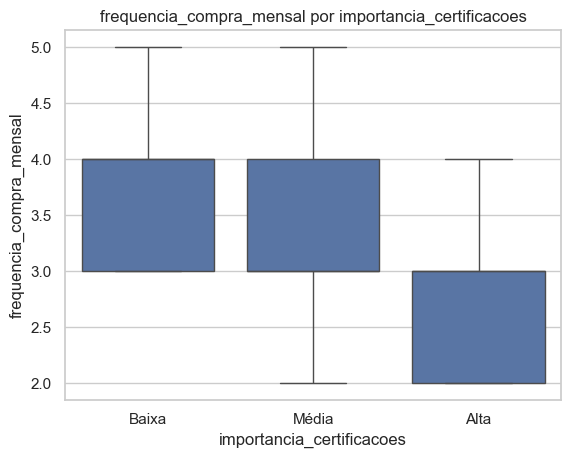


🔠 CATEGÓRICA × CATEGÓRICA


📌 tipo_cliente × aceita_refugo_como_mp


aceita_refugo_como_mp,Não,Sim
tipo_cliente,,
B2B,38.9,61.1
B2C,20.3,79.7


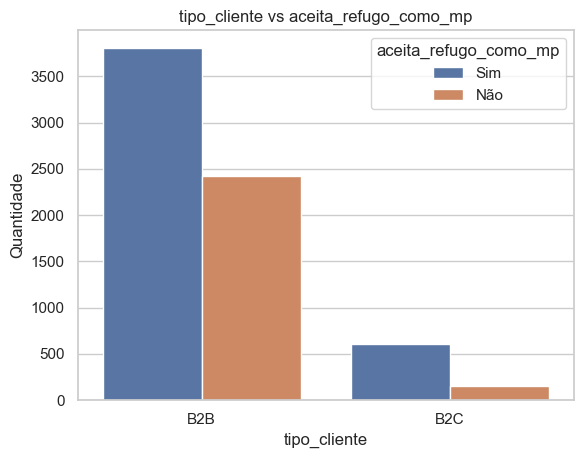


📌 tipo_cliente × importancia_preco


importancia_preco,Alta,Baixa,Média
tipo_cliente,,,
B2B,52.1,17.8,30.2
B2C,44.9,12.3,42.8


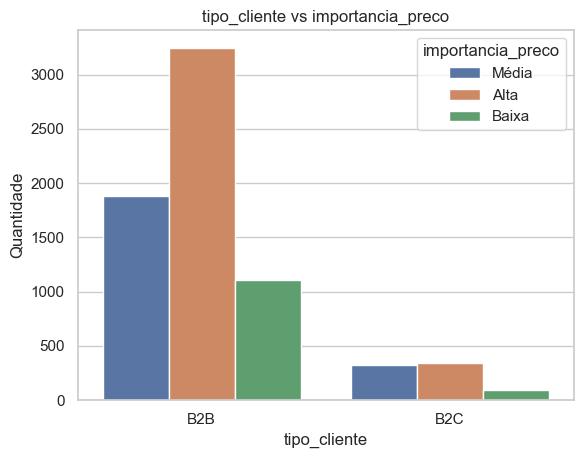


📌 tipo_cliente × importancia_certificacoes


importancia_certificacoes,Alta,Baixa,Média
tipo_cliente,,,
B2B,32.8,23.4,43.8
B2C,0.0,54.8,45.2


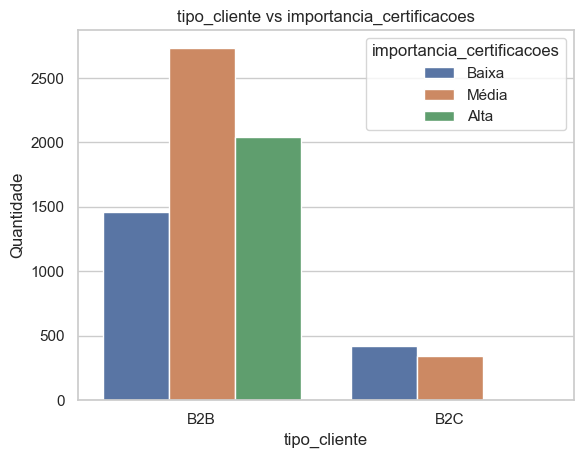


📌 aceita_refugo_como_mp × importancia_preco


importancia_preco,Alta,Baixa,Média
aceita_refugo_como_mp,,,
Não,35.3,33.3,31.4
Sim,60.7,7.7,31.6


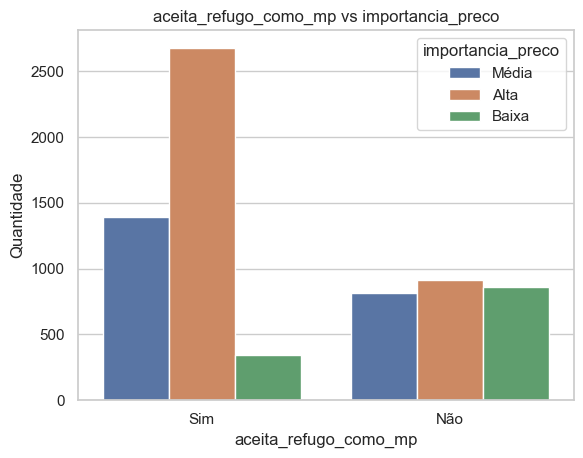


📌 aceita_refugo_como_mp × importancia_certificacoes


importancia_certificacoes,Alta,Baixa,Média
aceita_refugo_como_mp,,,
Não,52.5,13.9,33.6
Sim,15.6,34.4,50.0


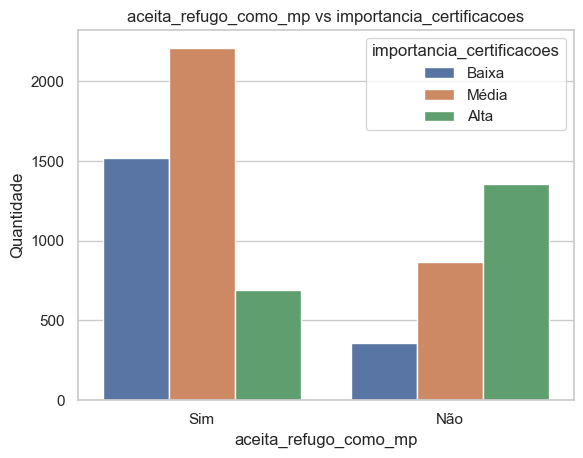


📌 importancia_preco × importancia_certificacoes


importancia_certificacoes,Alta,Baixa,Média
importancia_preco,,,
Alta,21.8,25.8,52.5
Baixa,61.5,14.1,24.4
Média,23.7,35.4,40.9


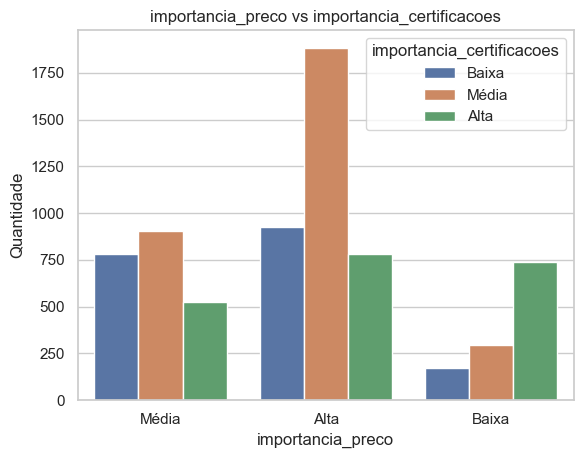

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ============================
# CONFIGURAÇÕES
# ============================
ordem_importancia = ['Baixa', 'Média', 'Alta']

num_vars = [
    'importancia_manga_produto_final_1a10',
    'volume_tipico_compra_ton_mes',
    'frequencia_compra_mensal'
]

cat_vars = [
    'tipo_cliente',
    'aceita_refugo_como_mp',
    'importancia_preco',
    'importancia_certificacoes'
]

# ============================
# 1. NUMÉRICA × NUMÉRICA
# ============================
print("🔢 NUMÉRICA × NUMÉRICA\n")

display(df[num_vars].corr(method='spearman'))

sns.pairplot(
    df[num_vars],
    kind='scatter',
    diag_kind='kde'
)
plt.suptitle("Relações entre variáveis numéricas", y=1.02)
plt.show()

# ============================
# 2. CATEGÓRICA × NUMÉRICA
# ============================
print("\n🔠 CATEGÓRICA × NUMÉRICA\n")

for cat in cat_vars:
    for num in num_vars:
        print(f"\n📌 {cat} × {num}")
        
        display(
            df
            .groupby(cat)[num]
            .describe()
            .round(2)
        )
        
        plt.figure()
        if cat in ['importancia_preco', 'importancia_certificacoes']:
            sns.boxplot(
                data=df,
                x=cat,
                y=num,
                order=ordem_importancia
            )
        else:
            sns.boxplot(
                data=df,
                x=cat,
                y=num
            )
        plt.title(f'{num} por {cat}')
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

# ============================
# 3. CATEGÓRICA × CATEGÓRICA
# ============================
print("\n🔠 CATEGÓRICA × CATEGÓRICA\n")

for i, var1 in enumerate(cat_vars):
    for var2 in cat_vars[i+1:]:
        print(f"\n📌 {var1} × {var2}")
        
        tabela = pd.crosstab(
            df[var1],
            df[var2],
            normalize='index'
        ) * 100
        
        display(tabela.round(1))
        
        plt.figure()
        sns.countplot(
            data=df,
            x=var1,
            hue=var2,
            order=ordem_importancia if var1 in ordem_importancia else None
        )
        plt.title(f'{var1} vs {var2}')
        plt.xlabel(var1)
        plt.ylabel('Quantidade')
        plt.show()
